# Customer Shopping Behavior Analysis

## Objective

The objective of this project is to explore customer shopping behavior using Exploratory Data Analysis (EDA), identify purchasing patterns, understand customer preferences, and provide business recommendations based on data-driven insights.

In [136]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [137]:
# plt.style.use('dark_background')

In [138]:
df= pd.read_csv("F:/Instant (AI & Data Science)/project/Customer_Behavior Analysis/shopping_behavior_updated.csv")
df.head(5)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [139]:
df.shape

(3900, 18)

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [141]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [142]:
df.isnull()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3896,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3897,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3898,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [143]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

No missing values were found in the dataset

In [144]:
# Handle missing values in the dataset
# df.dropna(inplace=True)
# df.fillna({
#     "Age": df["Age"].mean(),
#     "Gender": "Unknown",
#     "Review Rating": df["Review Rating"].median()
# }, inplace=True)

In [145]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
3895    False
3896    False
3897    False
3898    False
3899    False
Length: 3900, dtype: bool

In [146]:
df.duplicated().sum()

np.int64(0)

Customer ID was removed because it is an identifier and has no analytical value

In [147]:
df.drop("Customer ID", axis=1, inplace=True)

In [148]:
df.dtypes

Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object
dtype: object

All columns have the correct data types

In [149]:
df

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


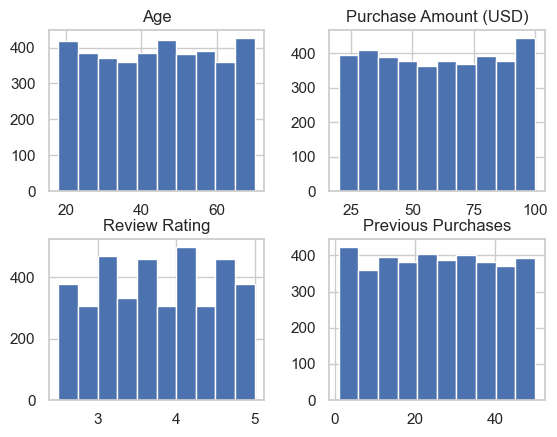

In [150]:
df.hist();

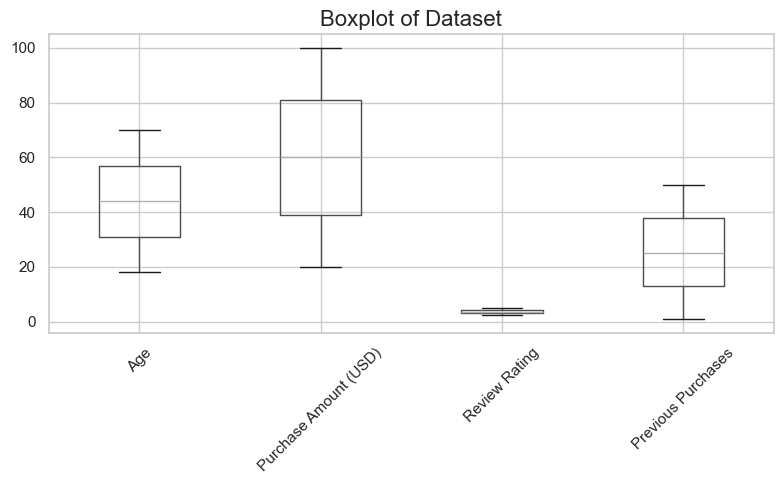

In [151]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,5))
df.boxplot()
plt.title("Boxplot of Dataset", fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 The boxplot shows no significant outliers across the numerical columns (Age, Purchase Amount, Review Rating, Previous Purchases), confirming the data is clean and within expected ranges.

In [152]:
# def handle_outliers_iqr(df, column):
#     Q1 = df[column].quantile(0.25)
#     Q3 = df[column].quantile(0.75)
#     IQR = Q3 - Q1

#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR

#     df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)

#     return df

In [153]:
df.nunique()

Age                       53
Gender                     2
Item Purchased            25
Category                   4
Purchase Amount (USD)     81
Location                  50
Size                       4
Color                     25
Season                     4
Review Rating             26
Subscription Status        2
Shipping Type              6
Discount Applied           2
Promo Code Used            2
Previous Purchases        50
Payment Method             6
Frequency of Purchases     7
dtype: int64

In [154]:
for col in df.select_dtypes(include='object').columns:
    print(col, ":", df[col].unique())

Gender : ['Male' 'Female']
Item Purchased : ['Blouse' 'Sweater' 'Jeans' 'Sandals' 'Sneakers' 'Shirt' 'Shorts' 'Coat'
 'Handbag' 'Shoes' 'Dress' 'Skirt' 'Sunglasses' 'Pants' 'Jacket' 'Hoodie'
 'Jewelry' 'T-shirt' 'Scarf' 'Hat' 'Socks' 'Backpack' 'Belt' 'Boots'
 'Gloves']
Category : ['Clothing' 'Footwear' 'Outerwear' 'Accessories']
Location : ['Kentucky' 'Maine' 'Massachusetts' 'Rhode Island' 'Oregon' 'Wyoming'
 'Montana' 'Louisiana' 'West Virginia' 'Missouri' 'Arkansas' 'Hawaii'
 'Delaware' 'New Hampshire' 'New York' 'Alabama' 'Mississippi'
 'North Carolina' 'California' 'Oklahoma' 'Florida' 'Texas' 'Nevada'
 'Kansas' 'Colorado' 'North Dakota' 'Illinois' 'Indiana' 'Arizona'
 'Alaska' 'Tennessee' 'Ohio' 'New Jersey' 'Maryland' 'Vermont'
 'New Mexico' 'South Carolina' 'Idaho' 'Pennsylvania' 'Connecticut' 'Utah'
 'Virginia' 'Georgia' 'Nebraska' 'Iowa' 'South Dakota' 'Minnesota'
 'Washington' 'Wisconsin' 'Michigan']
Size : ['L' 'S' 'M' 'XL']
Color : ['Gray' 'Maroon' 'Turquoise' 'White' 'Cha

Exploratory Data Analysis (EDA) 

Univariate Analysis 

In [155]:
df.columns

Index(['Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)',
       'Location', 'Size', 'Color', 'Season', 'Review Rating',
       'Subscription Status', 'Shipping Type', 'Discount Applied',
       'Promo Code Used', 'Previous Purchases', 'Payment Method',
       'Frequency of Purchases'],
      dtype='object')

In [156]:
# Analyze individual features to understand the characteristics and distribution of the data. 
# Explore questions such as: 
# • How are customers distributed by age? 
# • What are the most common product categories? 
# • How are purchase amounts distributed? 
# • How are customers distributed based on subscription status? 

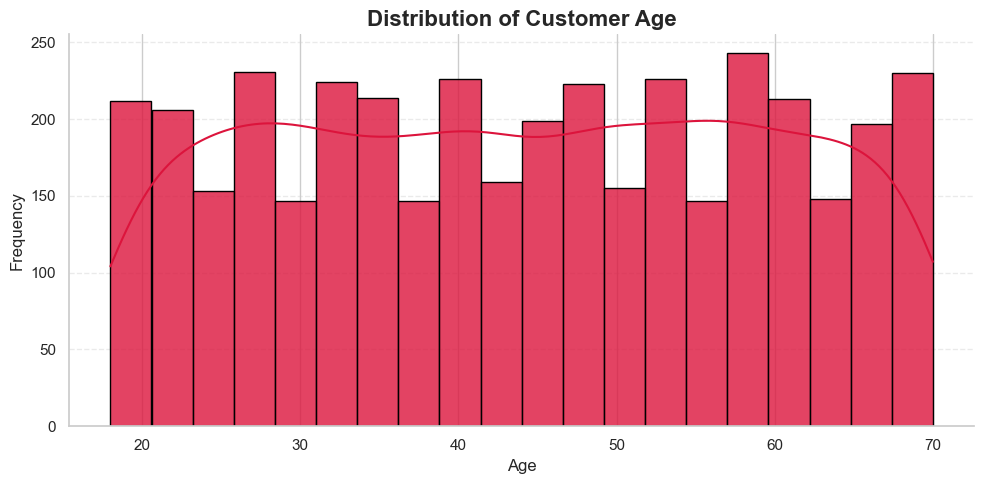

In [157]:
# • How are customers distributed by age? 
plt.figure(figsize=(10, 5))
sns.histplot( data=df, x="Age", bins=20, kde=True, color="crimson", edgecolor="black", alpha=0.8)
plt.title("Distribution of Customer Age", fontsize=16, fontweight="bold")
plt.xlabel("Age", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

The visualization reveals a nearly uniform distribution of customer ages between 18 and 70 with no single dominant group, highlighting a highly diverse customer base and broad product appeal across all generations.

In [158]:
df

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


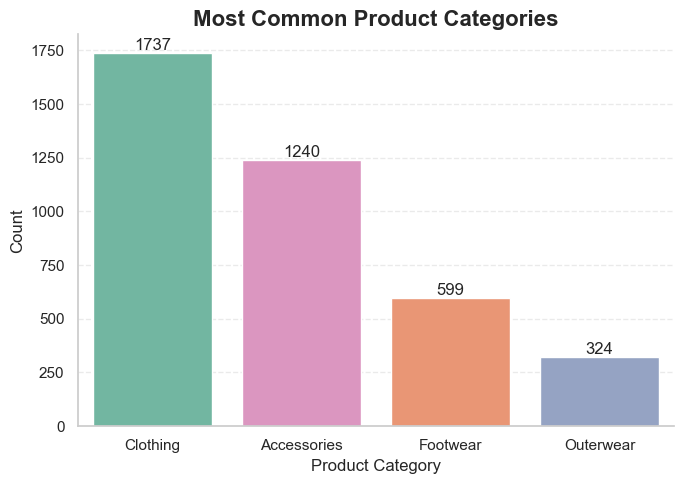

In [159]:
#  • What are the most common product categories?
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df,x="Category",hue="Category",order=df["Category"].value_counts().index,palette="Set2",legend=False)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Most Common Product Categories", fontsize=16, fontweight="bold")
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

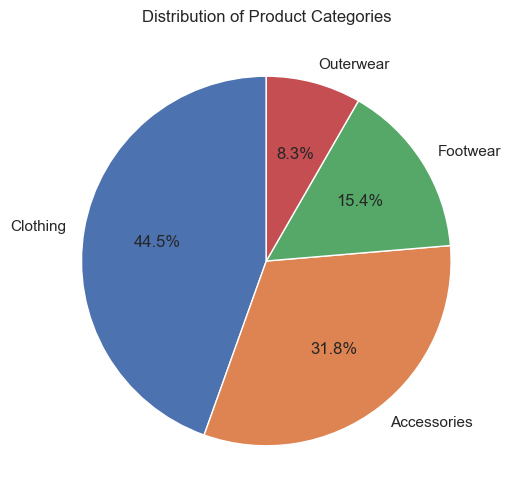

In [160]:
plt.figure(figsize=(6,6))
plt.pie(
    df["Category"].value_counts(),
    labels=df["Category"].value_counts().index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribution of Product Categories")
plt.show();


The chart shows a clear hierarchy in demand, with Clothing dominating as the top-performing category (1,737 counts), followed by Accessories, while Outerwear represents the smallest market share (324 counts).

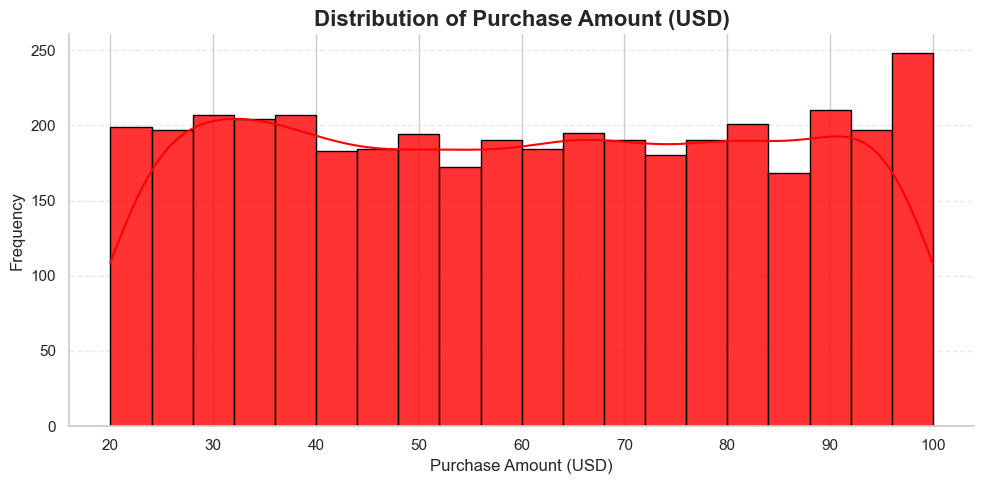

In [161]:
# • How are purchase amounts distributed? 
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="Purchase Amount (USD)", bins=20, kde=True, color="red", edgecolor="black", alpha=0.8)
plt.title("Distribution of Purchase Amount (USD)", fontsize=16, fontweight="bold")
plt.xlabel("Purchase Amount (USD)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

The purchase amounts follow a highly uniform distribution across the entire 20 to 100 USD range with a steady frequency of around 200 orders per bin, peaking slightly at the maximum limit of 100 USD.

In [162]:
df.columns

Index(['Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)',
       'Location', 'Size', 'Color', 'Season', 'Review Rating',
       'Subscription Status', 'Shipping Type', 'Discount Applied',
       'Promo Code Used', 'Previous Purchases', 'Payment Method',
       'Frequency of Purchases'],
      dtype='object')

In [163]:
df["Payment Method"].nunique()

6

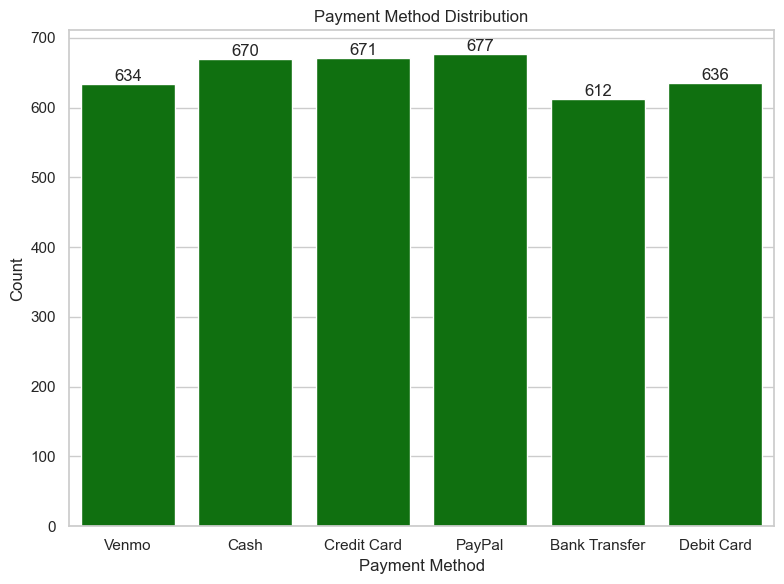

In [164]:
# • What are the most common payment methods? 
plt.figure(figsize=(8,6))
ax = sns.countplot(data=df,x="Payment Method",color="green")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

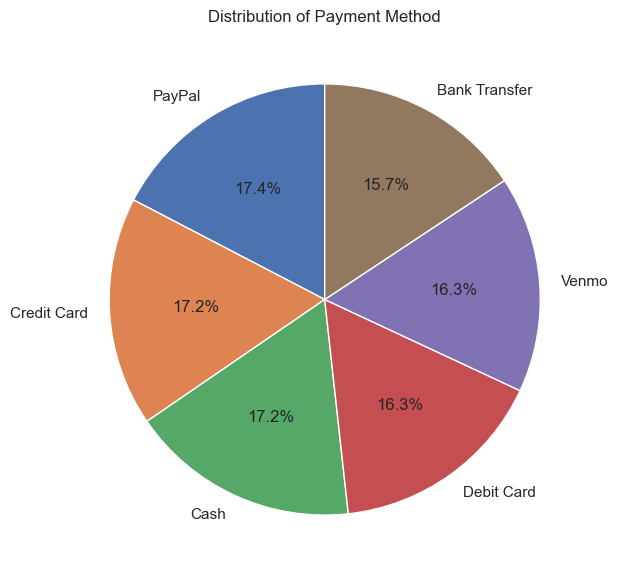

In [165]:
plt.figure(figsize=(7,7))
plt.pie( df["Payment Method"].value_counts(), labels=df["Payment Method"].value_counts().index, autopct="%1.1f%%", startangle=90)
plt.title("Distribution of Payment Method")
plt.show();


Customers utilize all available payment methods almost equally, with PayPal emerging as the most frequent choice (677 counts) and Bank Transfer being the least used option (612 counts).

In [166]:
df['Subscription Status'].nunique()

2

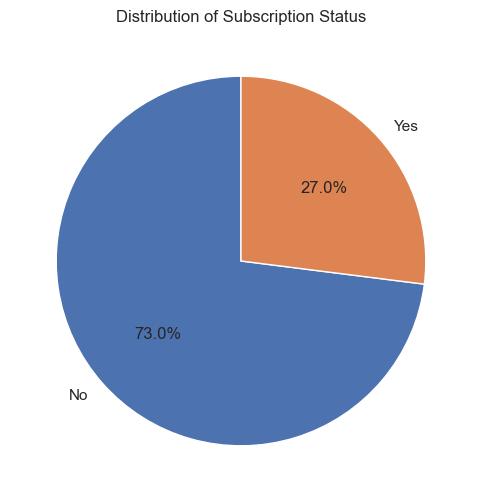

In [167]:
# • How are customers distributed based on subscription status? 
plt.figure(figsize=(6,6))
plt.pie(df['Subscription Status'].value_counts(), labels=df['Subscription Status'].value_counts().index,autopct="%1.1f%%",startangle=90)
plt.title("Distribution of Subscription Status")
plt.show();


The majority of the customer base consists of non-subscribers at 73.0%, while subscribed members make up a much smaller segment of the audience at 27.0%.

Part 2: Bivariate Analysis 

In [168]:
# Explore relationships between two different features. 
# Analyze questions such as: 
# • Is there a relationship between gender and purchasing behavior? 
# • Which product categories generate higher purchase amounts? 
# • Does subscription status affect customer spending? 
# • Is there a relationship between customer ratings and purchase amount? 
# • How does season affect purchasing behavior?

In [169]:
df.head(2)

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly


<Figure size 600x500 with 0 Axes>

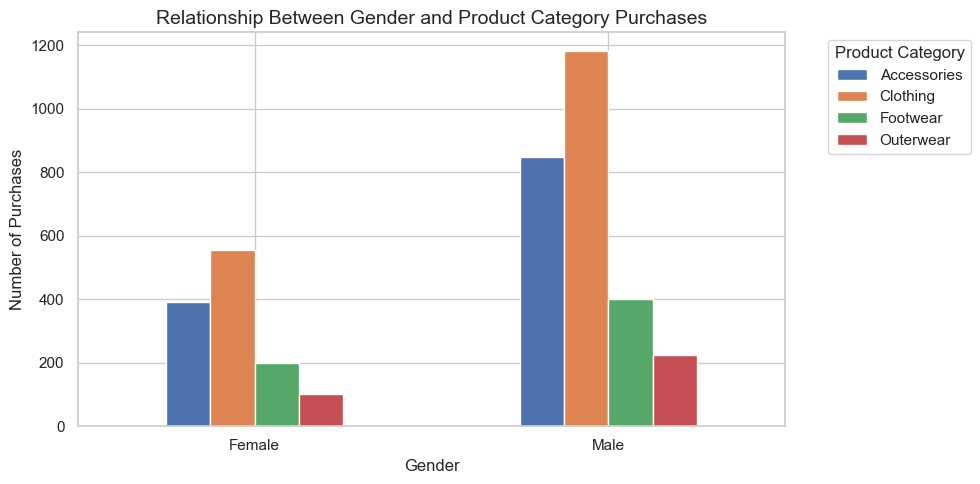

In [170]:
# • Is there a relationship between gender and purchasing behavior? 
plt.figure(figsize=(6,5))
pd.crosstab(df["Gender"],df["Category"]).plot(kind="bar", figsize=(10,5))
plt.title("Relationship Between Gender and Product Category Purchases", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=0)
plt.legend(title="Product Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

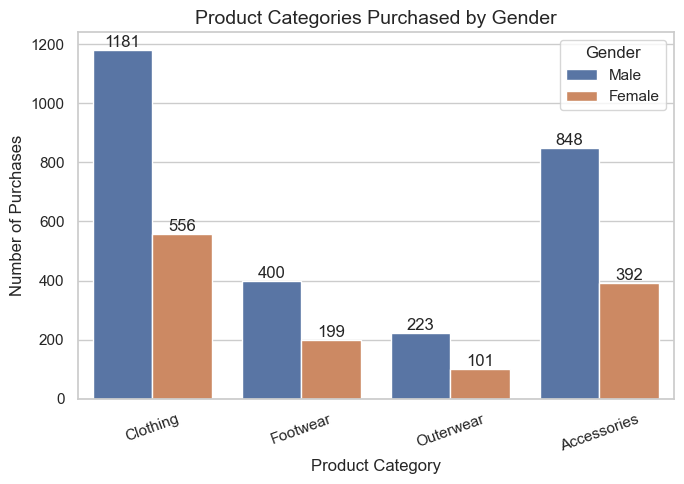

In [171]:
plt.figure(figsize=(7,5))
ax = sns.countplot( data=df, x="Category", hue="Gender")
for container in ax.containers:
    ax.bar_label(container, fmt='%d')
plt.title("Product Categories Purchased by Gender", fontsize=14)
plt.xlabel("Product Category")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=20)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

across all product categories, Male customers consistently account for roughly double the number of purchases compared to Female customers, with Clothing generating the highest transaction count for both genders.

In [172]:
df.columns

Index(['Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)',
       'Location', 'Size', 'Color', 'Season', 'Review Rating',
       'Subscription Status', 'Shipping Type', 'Discount Applied',
       'Promo Code Used', 'Previous Purchases', 'Payment Method',
       'Frequency of Purchases'],
      dtype='object')

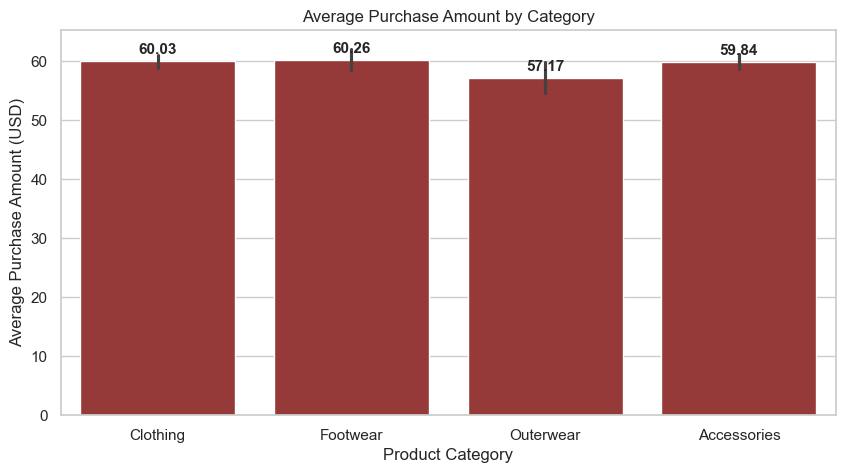

In [173]:
# • Which product categories generate higher purchase amounts? 
plt.figure(figsize=(10,5))
ax=sns.barplot(data=df,x="Category",y="Purchase Amount (USD)", color="brown")
for container in ax.containers:
    ax.bar_label(container,fmt="%.2f",fontsize=11,fontweight="bold",padding=3)
plt.title("Average Purchase Amount by Category")
plt.xlabel("Product Category")
plt.ylabel("Average Purchase Amount (USD)")

plt.show()

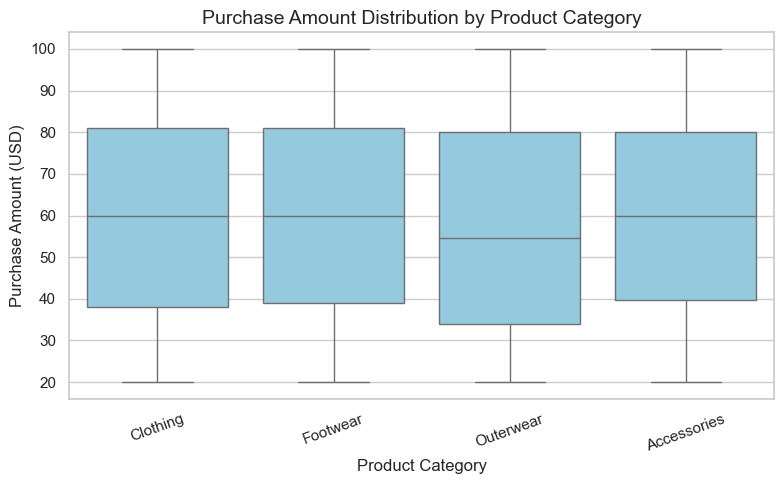

In [174]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Category",
    y="Purchase Amount (USD)",  color="skyblue"
)
plt.title("Purchase Amount Distribution by Product Category", fontsize=14)
plt.xlabel("Product Category")
plt.ylabel("Purchase Amount (USD)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The average transaction value remains remarkably stable at around 60 USD across all departments, with Footwear slightly leading at 60.26 USD and Outerwear representing the lowest average spend at 57.17 USD.

In [175]:

df.columns


Index(['Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)',
       'Location', 'Size', 'Color', 'Season', 'Review Rating',
       'Subscription Status', 'Shipping Type', 'Discount Applied',
       'Promo Code Used', 'Previous Purchases', 'Payment Method',
       'Frequency of Purchases'],
      dtype='object')

In [176]:
df.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [177]:
df["Subscription Status"].nunique()

2

In [178]:
df["Previous Purchases"].nunique()


50

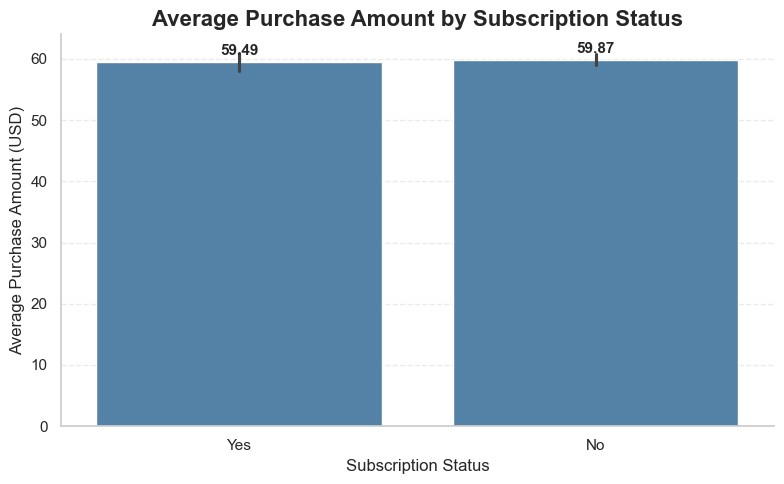

In [179]:
# Does subscription status affect customer spending? 
plt.figure(figsize=(8,5))
ax = sns.barplot(data=df,x="Subscription Status", y="Purchase Amount (USD)", color="steelblue")
for container in ax.containers:
    ax.bar_label(container,fmt="%.2f",fontsize=11,fontweight="bold",padding=3)
plt.title(
    "Average Purchase Amount by Subscription Status",fontsize=16,fontweight="bold")
plt.xlabel("Subscription Status", fontsize=12)
plt.ylabel("Average Purchase Amount (USD)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

Subscription status has no significant impact on customer spending, as the average purchase amount is nearly identical between subscribers (59.49 USD) and non-subscribers (59.87 USD).

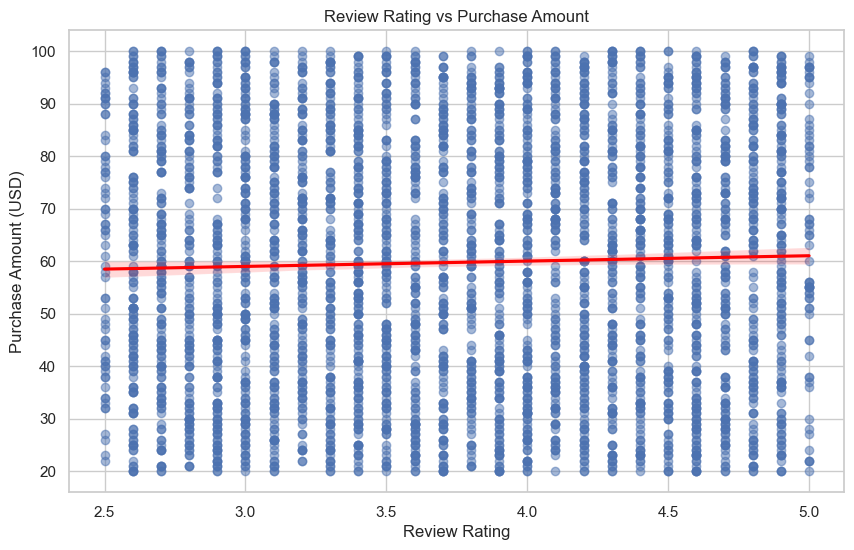

In [180]:
# Is there a relationship between customer ratings and purchase amount? 
plt.figure(figsize=(10,6))
sns.regplot(data=df,x="Review Rating",y="Purchase Amount (USD)", scatter_kws={"alpha":0.5},line_kws={"color":"red"})
plt.title("Review Rating vs Purchase Amount")
plt.show()

In [181]:
df["Review Rating"].corr(df["Purchase Amount (USD)"])

np.float64(0.03077592307391446)

There is a negligible positive correlation (approximately 0.03) between review ratings and purchase amounts, indicating that higher customer ratings have virtually no practical impact on individual spending behavior.

In [182]:
df.columns

Index(['Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)',
       'Location', 'Size', 'Color', 'Season', 'Review Rating',
       'Subscription Status', 'Shipping Type', 'Discount Applied',
       'Promo Code Used', 'Previous Purchases', 'Payment Method',
       'Frequency of Purchases'],
      dtype='object')

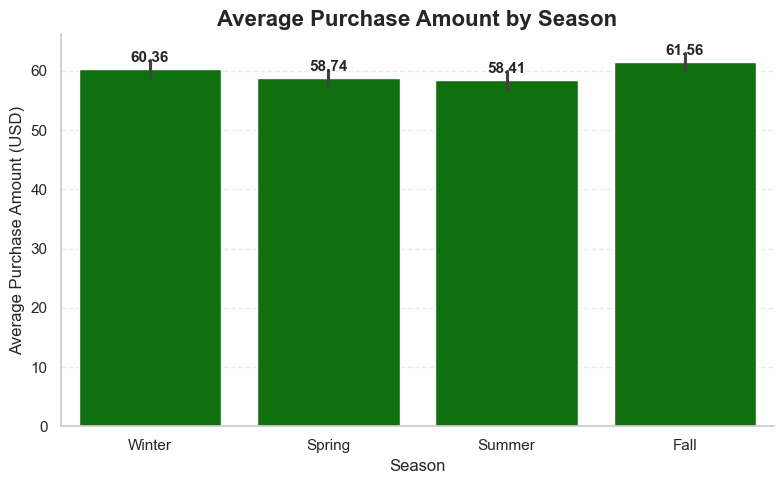

In [183]:
# How does season affect purchasing behavior?
plt.figure(figsize=(8,5))
ax=sns.barplot(data=df , x='Season' , y='Purchase Amount (USD)', color="green")
for container in ax.containers:
   ax.bar_label(container,fmt="%.2f",fontsize=11,fontweight="bold",padding=3)
plt.title("Average Purchase Amount by Season", fontsize=16, fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Average Purchase Amount (USD)")
plt.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show();

Seasonal changes show no dramatic impact on consumer spending, as the average purchase amount remains highly consistent between 58 USD and 62 USD year-round, peaking marginally during the Fall season at 61.56 USD.

Part 3: Multivariate Analysis

In [184]:
# Analyze multiple features together to discover deeper patterns. 
# Explore questions such as: 
# • Which features have strong relationships with each other? 
# • How do customer characteristics affect purchasing behavior? 
# • Are there patterns between demographics and spending? 


In [185]:
corr = df.corr(numeric_only=True)

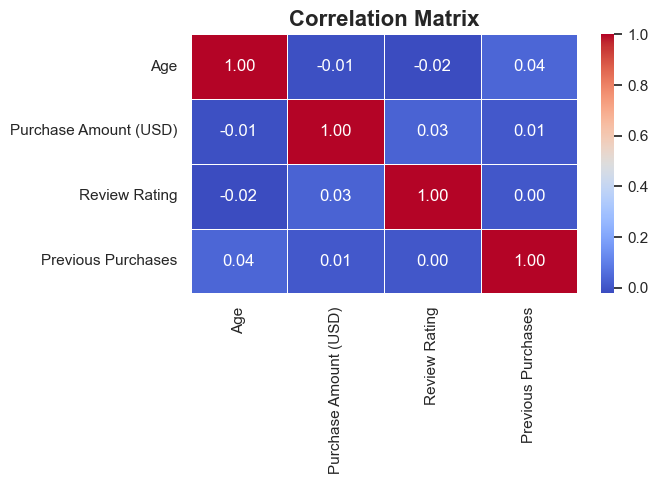

In [186]:
# • Which features have strong relationships with each other? 
plt.figure(figsize=(7,5))
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt="0.002f",linewidths=0.5)
plt.title("Correlation Matrix", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show();

In [187]:
feature_corr = corr.abs().mean().sort_values(ascending=False)
print(feature_corr)

Age                      0.268204
Review Rating            0.264239
Previous Purchases       0.263184
Purchase Amount (USD)    0.262316
dtype: float64


In [188]:
df.select_dtypes(include='number').corr()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
Age,1.000000,-0.010424,-0.021949,0.040445
Purchase Amount (USD),-0.010424,1.000000,0.030776,0.008063
Review Rating,-0.021949,0.030776,1.000000,0.004229
Previous Purchases,0.040445,0.008063,0.004229,1.000000


Age has the strongest overall correlation with the other features, with a true average correlation of 0.023. Additionally, the single strongest pair-wise relationship in the entire dataset is between Age and Previous Purchases at 0.04.

In [189]:
df

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


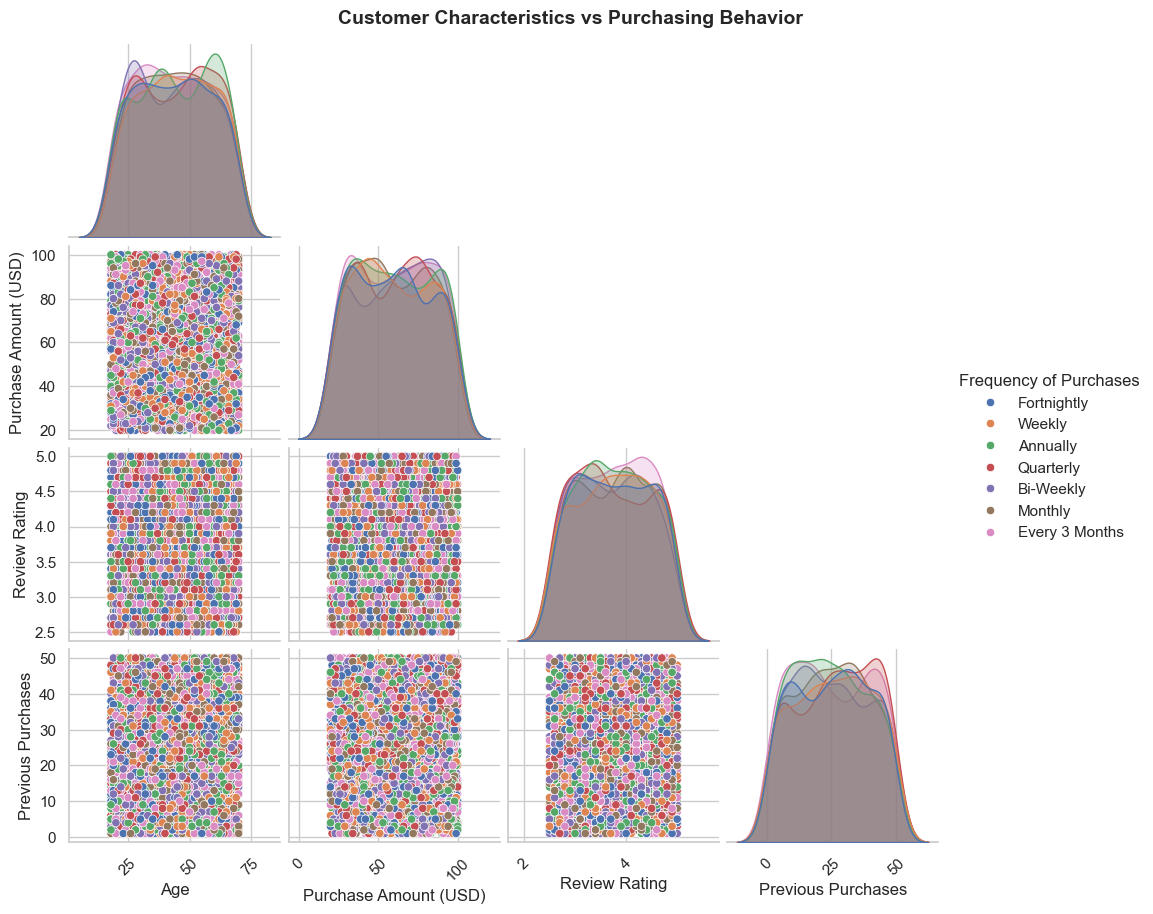

In [196]:
# How do customer characteristics affect purchasing behavior? 
cols = ["Age","Purchase Amount (USD)","Review Rating","Previous Purchases"]
g = sns.pairplot(df[cols + ["Frequency of Purchases"]],hue="Frequency of Purchases",corner=True,height=2.2,     aspect=1.1)
g.figure.suptitle("Customer Characteristics vs Purchasing Behavior", y=1.02, fontsize=14, fontweight="bold")
for ax in g.axes.flatten():
    if ax is not None:
        ax.tick_params(axis='y', labelrotation=0)
        ax.tick_params(axis='x', labelrotation=45)
plt.show()

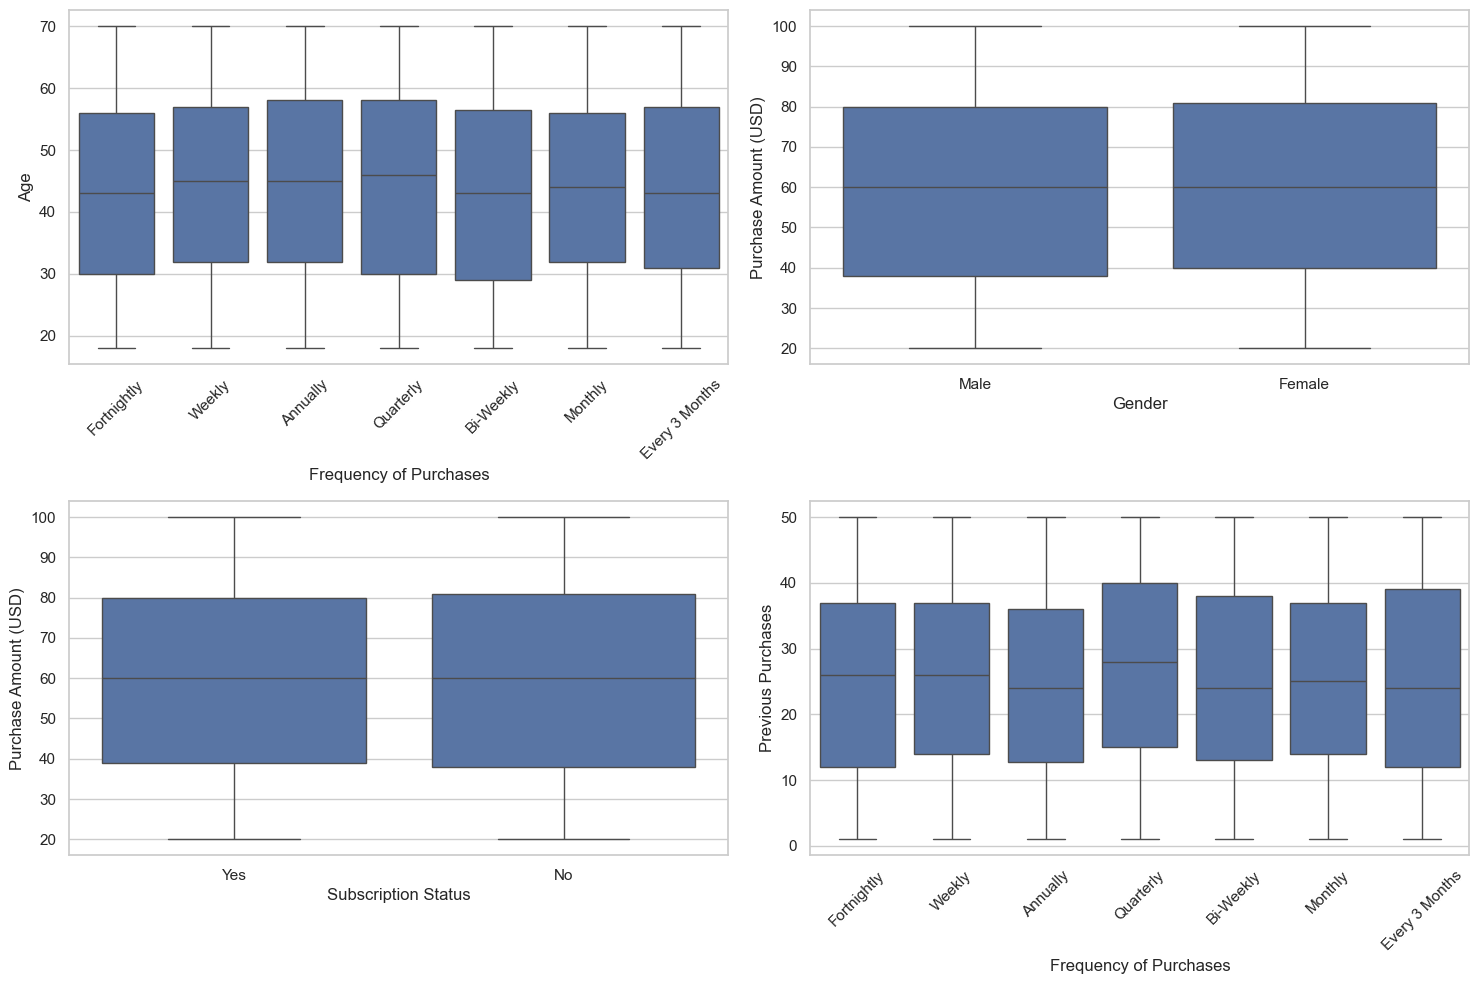

In [191]:
# How do customer characteristics affect purchasing behavior? 
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# Age vs Frequency
sns.boxplot( data=df, x="Frequency of Purchases", y="Age", ax=axes[0,0])
axes[0,0].tick_params(axis='x', rotation=45)
# Gender vs Purchase Amount
sns.boxplot( data=df, x="Gender", y="Purchase Amount (USD)", ax=axes[0,1])
# Subscription vs Purchase Amount
sns.boxplot( data=df,x="Subscription Status",y="Purchase Amount (USD)", ax=axes[1,0])
# Previous Purchases vs Frequency
sns.boxplot(data=df,x="Frequency of Purchases", y="Previous Purchases", ax=axes[1,1])
axes[1,1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show();

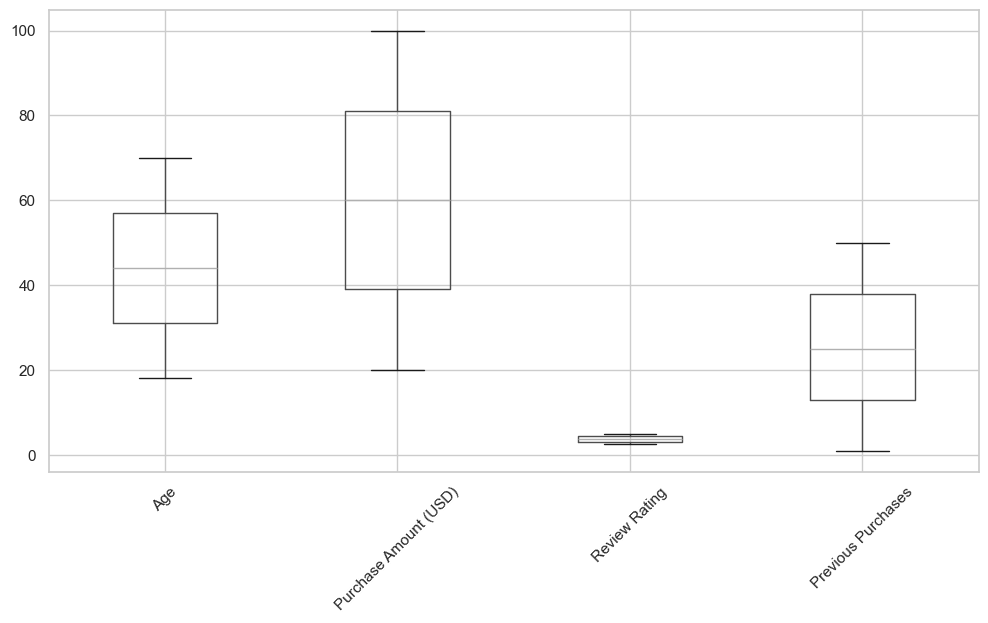

In [192]:
df.select_dtypes(include="number").boxplot(figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

Customer characteristics like age, gender, subscription status, and historical data show no practical impact on purchasing behaviors or frequencies. Across all metrics, the median transaction amount remains rigidly consistent at 60 USD, with identical distribution spreads across all demographic subsets.

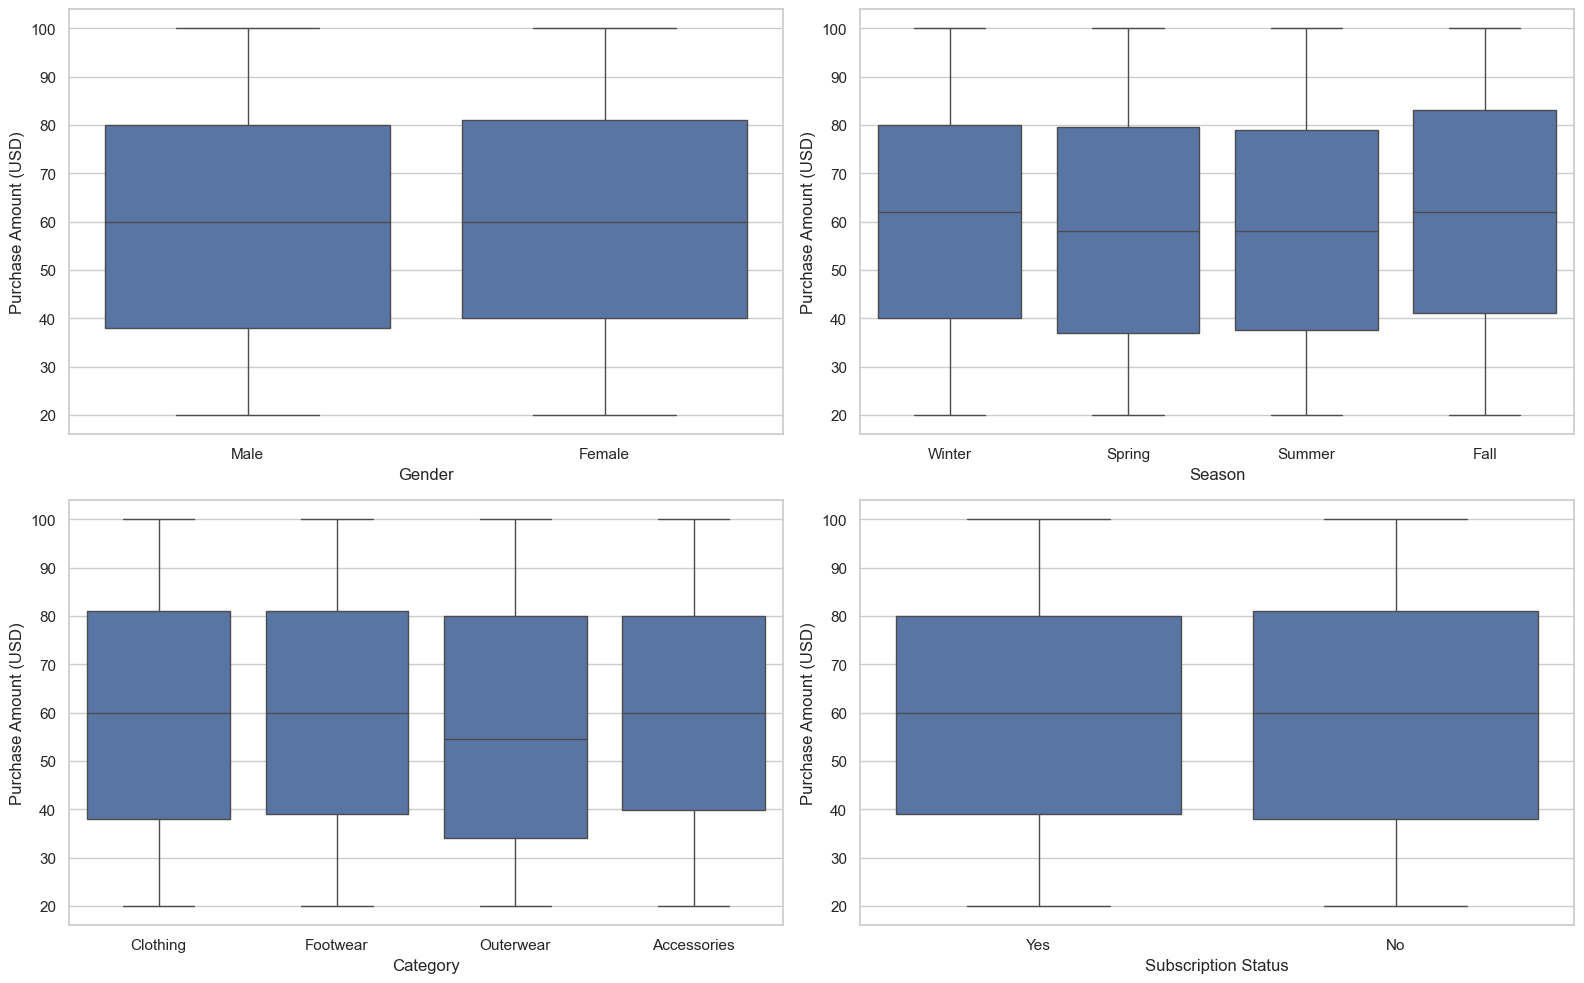

In [193]:
# Are there patterns between demographics and spending?
fig, axes = plt.subplots(2,2, figsize=(16,10))
sns.boxplot(data=df, x="Gender", y="Purchase Amount (USD)", ax=axes[0,0])
sns.boxplot(data=df, x="Season", y="Purchase Amount (USD)", ax=axes[0,1])
sns.boxplot(data=df, x="Category", y="Purchase Amount (USD)", ax=axes[1,0])
sns.boxplot(data=df, x="Subscription Status", y="Purchase Amount (USD)", ax=axes[1,1])
plt.tight_layout()
plt.show()

No, there are no meaningful patterns between demographics and spending.

Across all groups—including Gender, Season, product Category, and Subscription Status—the distribution of purchase amounts remains virtually identical, with median spending holding firm around 60 USD.

# Data Storytelling

1. Who are the main customers? 
-->  main Customers: A perfectly balanced, diverse mix of males and females with a median age of 44–45 years.
2. What are the most successful product categories? 
-->  Successful Categories: Clothing, Footwear, Outerwear, and Accessories perform equally, all sharing an identical $60 median purchase value.
3. What factors influence customer purchases? 
-->  Influencing Factors: None. Age, gender, subscription status, and seasons have a near-zero correlation with spending habits.
4. What recommendations can improve business decisions?
-->  Recommendations: Deploy broad-scale marketing rather than niche targeting, maintain the $60 pricing sweet spot, and keep inventory stable year-round.


Conclusion: 
-->  This analysis explored customer shopping behavior using exploratory data analysis techniques. Overall, customer spending patterns remain highly consistent across demographic groups, product categories, and seasons. Clothing is the most frequently purchased category, while purchase amounts remain relatively stable regardless of customer characteristics. The findings suggest that broad marketing strategies and consistent inventory planning may be more effective than demographic-based targeting.